<a href="https://colab.research.google.com/github/nehalnady/DM_Project/blob/main/DM_Classification_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# warnings.filterwarnings("ignore")

# from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report)
# from sklearn.feature_selection import SelectFromModel
# from imblearn.over_sampling import SMOTE




In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report)
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

# import kagglehub
# path = kagglehub.dataset_download("dhrubangtalukdar/telco-customer-churn-data")
# print(os.listdir(path))
# df = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())

# Preprocessing steps


df.drop(columns=["customerID"], inplace=True) # drop non_informative id column

# 1-remove any duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

# 2-Handeling missing values

missing = df.isnull().sum()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# 3- Encoding for variables

le = LabelEncoder()
binary_cols = ["gender", "Partner", "Dependents", "PhoneService",
"PaperlessBilling", "Churn"]
for col in binary_cols:
  df[col] = le.fit_transform(df[col])

multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
              "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
              "Contract", "PaymentMethod"]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"\n  Shape after encoding : {df.shape}")

# 4- feature scaling

X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 5- outlier detection

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
for col in num_cols:
    Q1, Q3 = X_scaled[col].quantile(0.25), X_scaled[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X_scaled[col] < Q1 - 1.5 * IQR) | (X_scaled[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  Outliers in {col:20s}: {outliers}")
    X_scaled[col] = X_scaled[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# 6- Feature selection

rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_scaled, y)
selector = SelectFromModel(rf_fs, prefit=True, threshold="mean")
X_selected = selector.transform(X_scaled)
selected_features = X.columns[selector.get_support()]

print(f"\n  Features after selection : {X_selected.shape[1]} / {X_scaled.shape[1]}")
print(f"  Selected : {list(selected_features)}")

# 7- Handle imbalance

X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
X_selected_df.fillna(X_selected_df.median(), inplace=True)
X_selected = X_selected_df.values
print(f"\n  Class distribution before SMOTE : {dict(pd.Series(y).value_counts())}")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_selected, y)
print(f"  Class distribution after  SMOTE : {dict(pd.Series(y_res).value_counts())}")




   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [9]:
# from google.colab import drive
# drive.mount('/content/drive')

In [10]:
# The spliting for dataset

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.20, random_state=42, stratify=y_res)
print(f"  Train : {X_train.shape[0]} samples   Test : {X_test.shape[0]} samples")
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
print(f"  Cross-val F1 (5-fold) : {cv_scores.round(4)}  →  mean = {cv_scores.mean():.4f}")
model.fit(X_train, y_train)






  Train : 8262 samples   Test : 2066 samples
  Cross-val F1 (5-fold) : [0.7851 0.7979 0.8165 0.7908 0.8047]  →  mean = 0.7990


GradientBoostingClassifier(max_depth=4, n_estimators=200, random_state=42)

In [11]:
# predication

new_samples = X_test[:5]
new_preds   = model.predict(new_samples)
new_proba   = model.predict_proba(new_samples)[:, 1]
for i, (pred, prob) in enumerate(zip(new_preds, new_proba)):
    label = "CHURN" if pred == 1 else "STAY"
    print(f"  Customer {i+1}: {label}  (churn probability = {prob:.2%})")

  Customer 1: STAY  (churn probability = 1.95%)
  Customer 2: CHURN  (churn probability = 72.86%)
  Customer 3: STAY  (churn probability = 19.63%)
  Customer 4: STAY  (churn probability = 25.86%)
  Customer 5: STAY  (churn probability = 47.32%)


In [12]:
# Evaulation

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Stay','Churn'])}")

  Accuracy  : 0.7812
  Precision : 0.7582
  Recall    : 0.8258
  F1-Score  : 0.7905
  ROC-AUC   : 0.8639

              precision    recall  f1-score   support

        Stay       0.81      0.74      0.77      1033
       Churn       0.76      0.83      0.79      1033

    accuracy                           0.78      2066
   macro avg       0.78      0.78      0.78      2066
weighted avg       0.78      0.78      0.78      2066



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


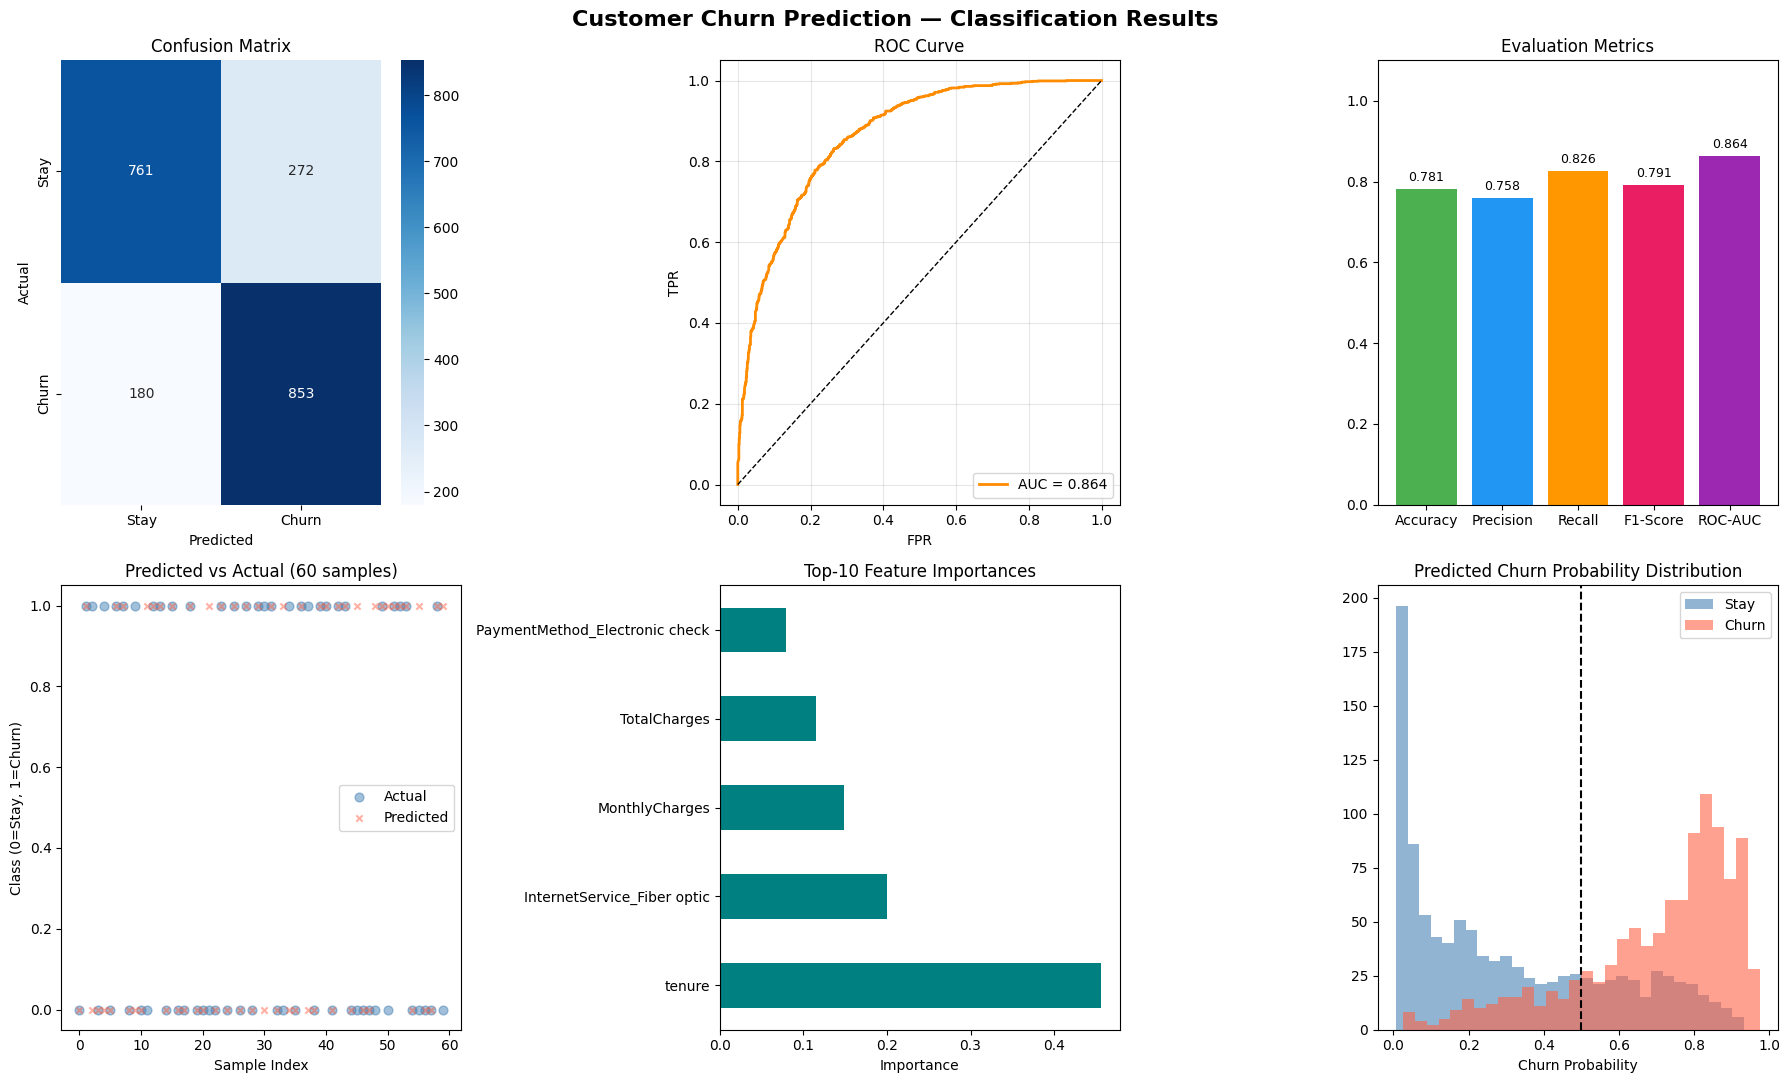

In [13]:
from google.colab import drive
drive.mount('/content/drive')

# visualizations

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Customer Churn Prediction — Classification Results", fontsize=16, fontweight="bold")

# 1. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0], xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
axes[0, 0].set_title("Confusion Matrix")

axes[0, 0].set_ylabel("Actual"); axes[0, 0].set_xlabel("Predicted")


# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

axes[0, 1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")

axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1)

axes[0, 1].set_title("ROC Curve"); axes[0, 1].set_xlabel("FPR"); axes[0, 1].set_ylabel("TPR")

axes[0, 1].legend(loc="lower right"); axes[0, 1].grid(True, alpha=0.3)


# 3. Metrics Bar Chart

metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "ROC-AUC": auc}

axes[0, 2].bar(metrics.keys(), metrics.values(), color=["#4CAF50","#2196F3","#FF9800","#E91E63","#9C27B0"])

axes[0, 2].set_ylim(0, 1.1); axes[0, 2].set_title("Evaluation Metrics")
for i, v in enumerate(metrics.values()):
    axes[0, 2].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

# 4. Predicted vs Actual (first 60 test samples)
n_show = 60
axes[1, 0].scatter(range(n_show), y_test[:n_show], alpha=0.5, label="Actual",   color="steelblue", s=40)
axes[1, 0].scatter(range(n_show), y_pred[:n_show], alpha=0.5, label="Predicted", color="tomato",    s=20, marker="x")
axes[1, 0].set_title("Predicted vs Actual (60 samples)")
axes[1, 0].set_xlabel("Sample Index"); axes[1, 0].set_ylabel("Class (0=Stay, 1=Churn)")
axes[1, 0].legend()

# 5. Feature Importances

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=selected_features).nlargest(10)

feat_imp.plot(kind="barh", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Top-10 Feature Importances"); axes[1, 1].set_xlabel("Importance")

# 6. Churn Probability Distribution

axes[1, 2].hist(y_proba[y_test == 0], bins=30, alpha=0.6, label="Stay",  color="steelblue")

axes[1, 2].hist(y_proba[y_test == 1], bins=30, alpha=0.6, label="Churn", color="tomato")
axes[1, 2].axvline(0.5, color="black", linestyle="--", linewidth=1.5)

axes[1, 2].set_title("Predicted Churn Probability Distribution")
axes[1, 2].set_xlabel("Churn Probability"); axes[1, 2].legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/task1_classification_churn.png",
            dpi=150, bbox_inches="tight")
plt.show()